In [111]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,LabelEncoder

from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


ohe gende,allergy,occupaton_type,comordities


In [112]:
data=pd.read_csv('synthetic_asthma_dataset.csv')
data

,Patient_ID,Age,Gender,BMI,Smoking_Status,Family_History,Allergies,Air_Pollution_Level,Physical_Activity_Level,Occupation_Type,Comorbidities,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma,Asthma_Control_Level
0,ASTH100000,52,Female,27.6,Former,1,NaN,Moderate,Sedentary,Outdoor,Diabetes,0.38,0,421.0,46.0,0,NaN
1,ASTH100001,15,Male,24.6,Former,0,Dust,Low,Moderate,Indoor,Both,0.60,2,297.6,22.9,0,NaN
2,ASTH100002,72,Female,17.6,Never,0,NaN,Moderate,Moderate,Indoor,NaN,0.38,0,303.3,15.3,0,NaN
3,ASTH100003,61,Male,16.8,Never,0,Multiple,High,Sedentary,Outdoor,Both,0.60,1,438.0,40.1,1,Poorly Controlled
4,ASTH100004,21,Male,30.2,Never,0,NaN,Moderate,Active,Indoor,NaN,0.82,3,535.0,27.7,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,ASTH109995,70,Male,25.0,Never,0,NaN,Low,Sedentary,Indoor,NaN,0.67,0,580.6,18.7,0,NaN
9996,ASTH109996,78,Female,24.8,Never,0,Pollen,Low,Moderate,Indoor,Diabetes,0.72,1,417.6,40.8,0,NaN
9997,ASTH109997,58,Male,30.1,Former,1,Pollen,Low,Moderate,Indoor,NaN,0.28,0,459.1,20.3,1,Not Controlled
9998,ASTH109998,88,Female,31.2,Former,0,Pollen,Moderate,Moderate,Indoor,NaN,0.44,0,415.9,25.0,0,NaN


In [113]:
data['Comorbidities'].value_counts()

,count
Comorbidities,
Diabetes,2029
Hypertension,2018
Both,986


In [114]:
data.shape

(10000, 17)

In [115]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               10000 non-null  object 
 1   Age                      10000 non-null  int64  
 2   Gender                   10000 non-null  object 
 3   BMI                      10000 non-null  float64
 4   Smoking_Status           10000 non-null  object 
 5   Family_History           10000 non-null  int64  
 6   Allergies                7064 non-null   object 
 7   Air_Pollution_Level      10000 non-null  object 
 8   Physical_Activity_Level  10000 non-null  object 
 9   Occupation_Type          10000 non-null  object 
 10  Comorbidities            5033 non-null   object 
 11  Medication_Adherence     10000 non-null  float64
 12  Number_of_ER_Visits      10000 non-null  int64  
 13  Peak_Expiratory_Flow     10000 non-null  float64
 14  FeNO_Level             

In [116]:
data.duplicated().sum()

np.int64(0)

In [117]:
data.isnull().sum()/100

,0
Patient_ID,0.00
Age,0.00
Gender,0.00
BMI,0.00
Smoking_Status,0.00
Family_History,0.00
Allergies,29.36
Air_Pollution_Level,0.00
Physical_Activity_Level,0.00
Occupation_Type,0.00


In [118]:
corr=data.corr(numeric_only=True)
corr

,Age,BMI,Family_History,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma
Age,1.000000,-0.010078,0.007481,-0.005332,-0.014775,0.012447,0.012180,-0.004346
BMI,-0.010078,1.000000,-0.001244,-0.001318,0.003024,-0.000559,-0.005137,0.098425
Family_History,0.007481,-0.001244,1.000000,0.019463,0.020411,-0.009463,0.005389,0.409531
Medication_Adherence,-0.005332,-0.001318,0.019463,1.000000,-0.001243,-0.012747,0.019040,0.003785
Number_of_ER_Visits,-0.014775,0.003024,0.020411,-0.001243,1.000000,0.001293,0.009969,0.005781
Peak_Expiratory_Flow,0.012447,-0.000559,-0.009463,-0.012747,0.001293,1.000000,0.000575,-0.005207
FeNO_Level,0.012180,-0.005137,0.005389,0.019040,0.009969,0.000575,1.000000,0.007012
Has_Asthma,-0.004346,0.098425,0.409531,0.003785,0.005781,-0.005207,0.007012,1.000000


<Axes: >

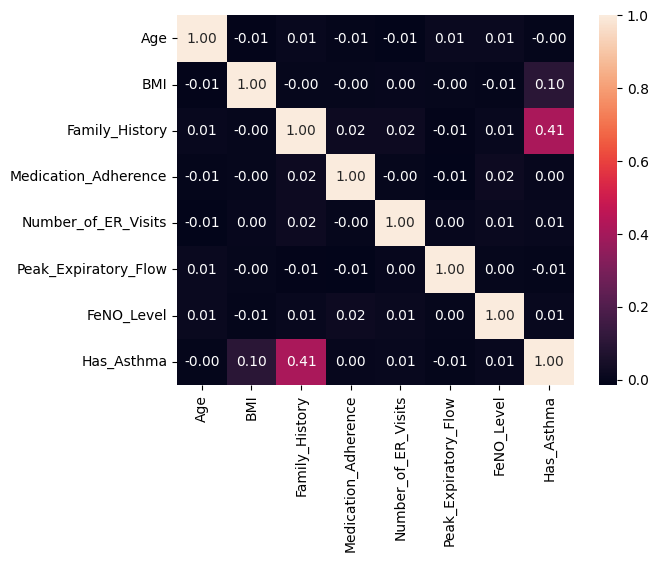

In [119]:
sns.heatmap(corr,annot=True,fmt='.2f')

In [120]:
data.describe()

,Age,BMI,Family_History,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,44.930700,25.053320,0.303400,0.497998,1.015900,400.884090,25.101420,0.243300
std,25.653559,4.874466,0.459749,0.224809,1.020564,97.531113,9.840184,0.429096
min,1.000000,15.000000,0.000000,0.000000,0.000000,150.000000,5.000000,0.000000
25%,23.000000,21.600000,0.000000,0.320000,0.000000,334.800000,18.200000,0.000000
50%,45.000000,25.000000,0.000000,0.500000,1.000000,402.500000,25.000000,0.000000
75%,67.000000,28.400000,1.000000,0.670000,2.000000,468.700000,31.700000,0.000000
max,89.000000,45.000000,1.000000,0.990000,6.000000,600.000000,63.900000,1.000000


In [121]:
data.drop(columns=['Patient_ID'],inplace=True)
data

,Age,Gender,BMI,Smoking_Status,Family_History,Allergies,Air_Pollution_Level,Physical_Activity_Level,Occupation_Type,Comorbidities,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma,Asthma_Control_Level
0,52,Female,27.6,Former,1,NaN,Moderate,Sedentary,Outdoor,Diabetes,0.38,0,421.0,46.0,0,NaN
1,15,Male,24.6,Former,0,Dust,Low,Moderate,Indoor,Both,0.60,2,297.6,22.9,0,NaN
2,72,Female,17.6,Never,0,NaN,Moderate,Moderate,Indoor,NaN,0.38,0,303.3,15.3,0,NaN
3,61,Male,16.8,Never,0,Multiple,High,Sedentary,Outdoor,Both,0.60,1,438.0,40.1,1,Poorly Controlled
4,21,Male,30.2,Never,0,NaN,Moderate,Active,Indoor,NaN,0.82,3,535.0,27.7,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,70,Male,25.0,Never,0,NaN,Low,Sedentary,Indoor,NaN,0.67,0,580.6,18.7,0,NaN
9996,78,Female,24.8,Never,0,Pollen,Low,Moderate,Indoor,Diabetes,0.72,1,417.6,40.8,0,NaN
9997,58,Male,30.1,Former,1,Pollen,Low,Moderate,Indoor,NaN,0.28,0,459.1,20.3,1,Not Controlled
9998,88,Female,31.2,Former,0,Pollen,Moderate,Moderate,Indoor,NaN,0.44,0,415.9,25.0,0,NaN


In [122]:
data.columns

Index(['Age', 'Gender', 'BMI', 'Smoking_Status', 'Family_History', 'Allergies',
       'Air_Pollution_Level', 'Physical_Activity_Level', 'Occupation_Type',
       'Comorbidities', 'Medication_Adherence', 'Number_of_ER_Visits',
       'Peak_Expiratory_Flow', 'FeNO_Level', 'Has_Asthma',
       'Asthma_Control_Level'],
      dtype='object')

In [123]:
cat=['Gender','Smoking_Status', 'Allergies',
       'Air_Pollution_Level', 'Physical_Activity_Level', 'Occupation_Type',
       'Comorbidities',
       'Asthma_Control_Level' ]

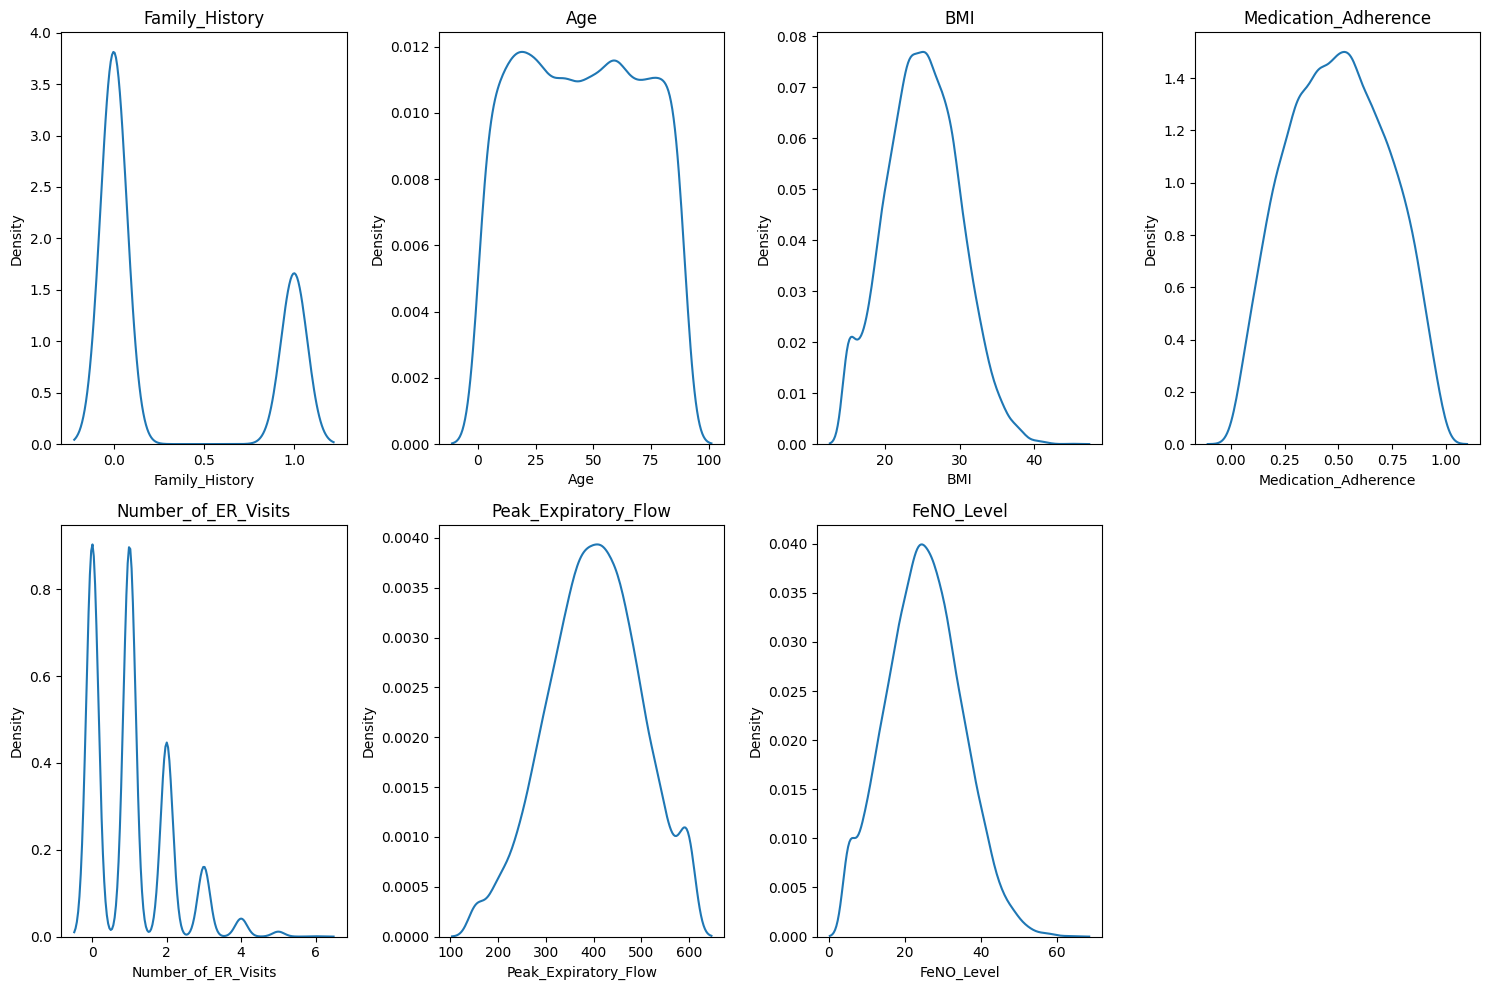

In [124]:
num=[ 'Family_History','Age','BMI', 'Medication_Adherence', 'Number_of_ER_Visits','Peak_Expiratory_Flow', 'FeNO_Level']

plt.figure(figsize=(15, 10))
for index, column_name in enumerate(num):
    plt.subplot(2, 4, index + 1)
    plt.title(column_name)
    sns.kdeplot(data[column_name])
plt.tight_layout()
plt.show()

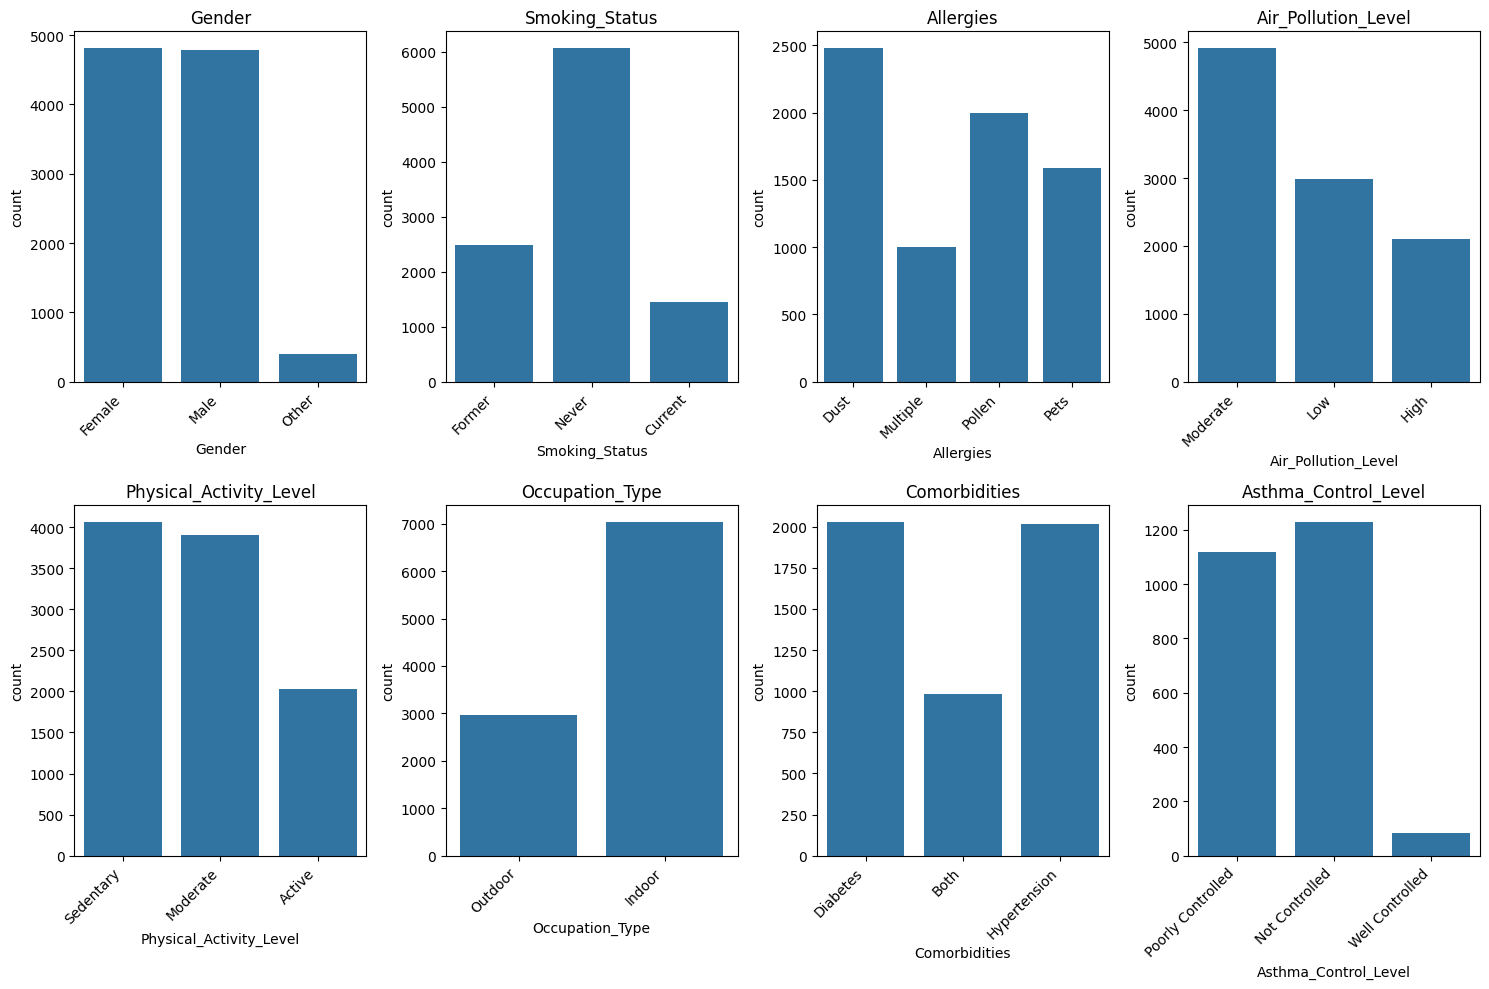

In [125]:
cat=['Gender','Smoking_Status', 'Allergies',
       'Air_Pollution_Level', 'Physical_Activity_Level', 'Occupation_Type',
       'Comorbidities',
       'Asthma_Control_Level' ]

plt.figure(figsize=(15, 10))

for index, column_name in enumerate(cat): # 'index' for subplot position, 'column_name' for actual column
  plt.subplot(2,4, index + 1) # Use 'index + 1' for the subplot number
  plt.title(column_name) # Use 'column_name' for the title

  sns.countplot(x=column_name, data=data)
  plt.xticks(rotation=45, ha='right') # Rotate labels for readability if they overlap

plt.tight_layout()
plt.show()

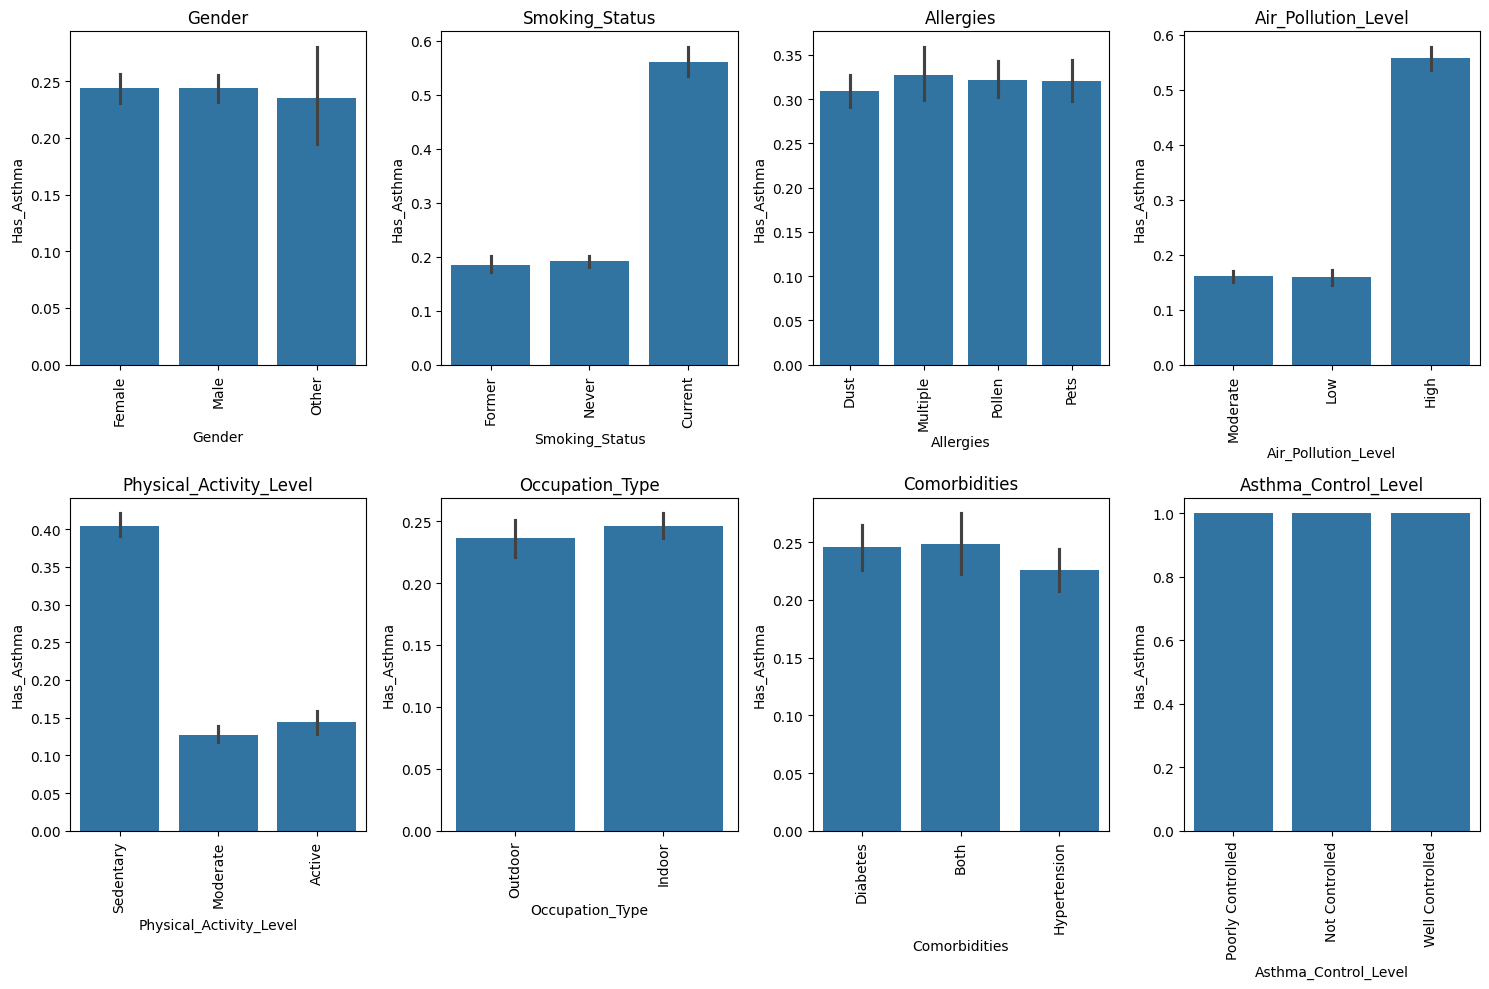

In [126]:

plt.figure(figsize=(15, 10))

for index,column_name in enumerate(cat):
  plt.subplot(2,4,index+1)
  plt.title(column_name)

  sns.barplot(y=data['Has_Asthma'],x=data[column_name])
  plt.xticks(rotation=90)
  plt.tight_layout()

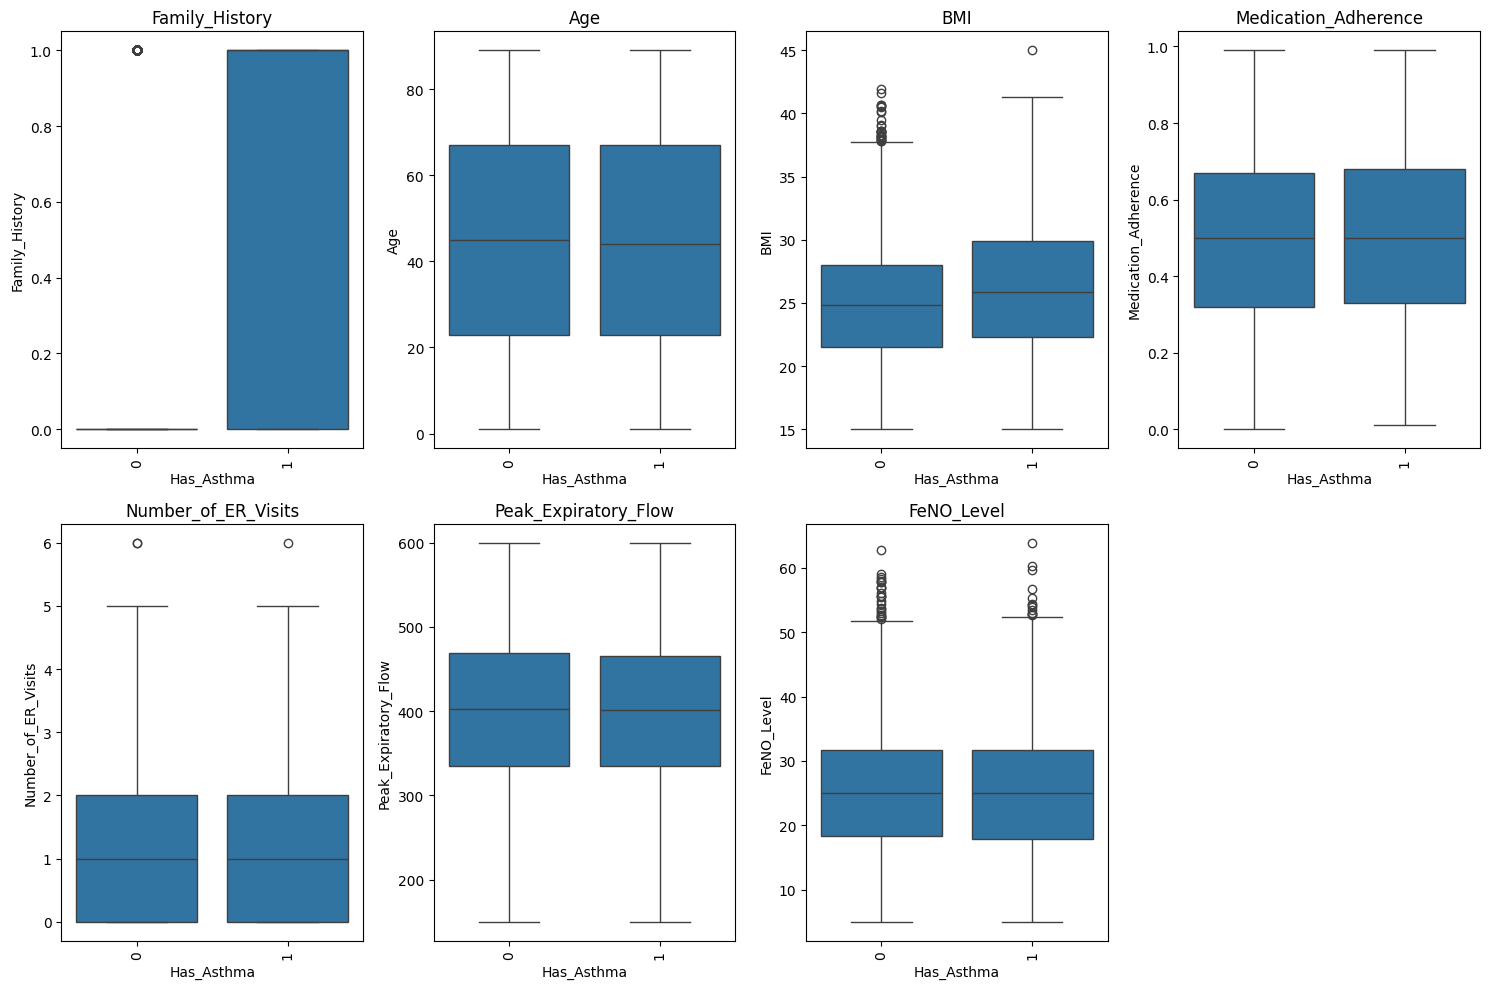

In [127]:
plt.figure(figsize=(15, 10))

for index,column_name in enumerate(num):
  plt.subplot(2,4,index+1)
  plt.title(column_name)

  sns.boxplot(x=data['Has_Asthma'],y=data[column_name])
  plt.xticks(rotation=90)
  plt.tight_layout()

In [128]:
data.drop(columns=['Asthma_Control_Level'],inplace=True)

In [129]:
data['Has_Asthma'].value_counts()

,count
Has_Asthma,
0,7567
1,2433


In [130]:
data.columns

Index(['Age', 'Gender', 'BMI', 'Smoking_Status', 'Family_History', 'Allergies',
       'Air_Pollution_Level', 'Physical_Activity_Level', 'Occupation_Type',
       'Comorbidities', 'Medication_Adherence', 'Number_of_ER_Visits',
       'Peak_Expiratory_Flow', 'FeNO_Level', 'Has_Asthma'],
      dtype='object')

In [131]:
data.columns

Index(['Age', 'Gender', 'BMI', 'Smoking_Status', 'Family_History', 'Allergies',
       'Air_Pollution_Level', 'Physical_Activity_Level', 'Occupation_Type',
       'Comorbidities', 'Medication_Adherence', 'Number_of_ER_Visits',
       'Peak_Expiratory_Flow', 'FeNO_Level', 'Has_Asthma'],
      dtype='object')

In [132]:
num_cols = ['Age', 'BMI', 'Family_History', 'Medication_Adherence', 'Number_of_ER_Visits', 'Peak_Expiratory_Flow', 'FeNO_Level']

# Define pipelines for transformations
cat_ohe_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

cat_ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

clf1=ColumnTransformer([
    ('gender_occ_ohe', OneHotEncoder(handle_unknown='ignore'), ['Gender','Occupation_Type']),
    ('allergies_comorb_ohe', cat_ohe_pipeline, ['Allergies','Comorbidities']),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),['Smoking_Status','Air_Pollution_Level','Physical_Activity_Level'])
],remainder='passthrough')

In [133]:
pipe=Pipeline([
    ('clf1',clf1),
    ('lr',LogisticRegression())
])

In [134]:
x=data.drop(columns=['Has_Asthma'])
y=data['Has_Asthma']

In [135]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [136]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [137]:
pipe.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppr

Pipeline(steps=[('clf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('gender_occ_ohe',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender',
                                                   'Occupation_Type']),
                                                 ('allergies_comorb_ohe',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='None',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Allergies',
                                                   'Comorbidities']),
                                                 ('ordinal',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['Smoking_Status',
                                                   'Air_Pollution_Level',
                                                   'Physical_Activity_Level'])])),
                ('lr', LogisticRegression())])

In [138]:
y_pred=pipe.predict(x_test)

In [147]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
accuracy_score(y_test,y_pred)

0.914

In [149]:
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1504
           1       1.00      1.00      1.00       496

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [140]:
pipe2=Pipeline([
    ('clf1',clf1),
    ('xg',XGBClassifier())
])

In [141]:
pipe2.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('clf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('gender_occ_ohe',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender',
                                                   'Occupation_Type']),
                                                 ('allergies_comorb_ohe',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='None',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Allergies',
                                                   'Comorbiditie...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [142]:
y_pred2=pipe2.predict(x_test)

In [143]:
accuracy_score(y_test,y_pred2)

0.9995

In [146]:
report=classification_report(y_test,y_pred2)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1504
           1       1.00      1.00      1.00       496

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [148]:
confusion_matrix(y_test,y_pred2)

array([[1503,    1],
       [   0,  496]])

In [150]:
pipe3=Pipeline([
    ('clf1',clf1),
    ('rf',RandomForestClassifier())
])

In [151]:
pipe3.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('clf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('gender_occ_ohe',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender',
                                                   'Occupation_Type']),
                                                 ('allergies_comorb_ohe',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='None',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Allergies',
                                                   'Comorbidities']),
                                                 ('ordinal',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['Smoking_Status',
                                                   'Air_Pollution_Level',
                                                   'Physical_Activity_Level'])])),
                ('rf', RandomForestClassifier())])

In [152]:
y_pred3=pipe3.predict(x_test)

In [153]:
accuracy_score(y_test,y_pred3)

0.9955

In [154]:
confusion_matrix(y_test,y_pred3)

array([[1504,    0],
       [   9,  487]])

In [155]:
report=classification_report(y_test,y_pred3)
print(report)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1504
           1       1.00      0.98      0.99       496

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



# Pipe2 with XGBoost is performing well